#GSE138852 阿尔兹海默症单细胞初步分析

In [6]:
!pip install scanpy pandas matplotlib anndata

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple


#1.环境载入与数据读取

In [7]:
import pandas as pd
import scanpy as sc

sc.settings.verbosity = 3
sc.set_figure_params(dpi=80,facecolor='white')

print("正在读取矩阵...")
counts = pd.read_csv('data/GSE138852_counts.csv.gz', index_col=0)
adata =sc.AnnData(counts.T)

print("正在读取注释信息...")
metadata = pd.read_csv('data/GSE138852_covariates.csv.gz',index_col=0)

adata.obs = metadata

print("真实AD数据加载成功！")
print(f"你的数据现在有{adata.n_obs}个细胞，每个细胞测到了{adata.n_vars}个基因。")
print(adata)



正在读取矩阵...
正在读取注释信息...
真实AD数据加载成功！
你的数据现在有13214个细胞，每个细胞测到了10850个基因。
AnnData object with n_obs × n_vars = 13214 × 10850
    obs: 'oupSample.batchCond', 'oupSample.cellType', 'oupSample.cellType_batchCond', 'oupSample.subclustID', 'oupSample.subclustCond'


In [8]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(adata,qc_vars=['mt'],percent_top=None,log1p=False,inplace=True)

print("质量指针计算完成！")

质量指针计算完成！


##2.质量控制（QC）小提琴图

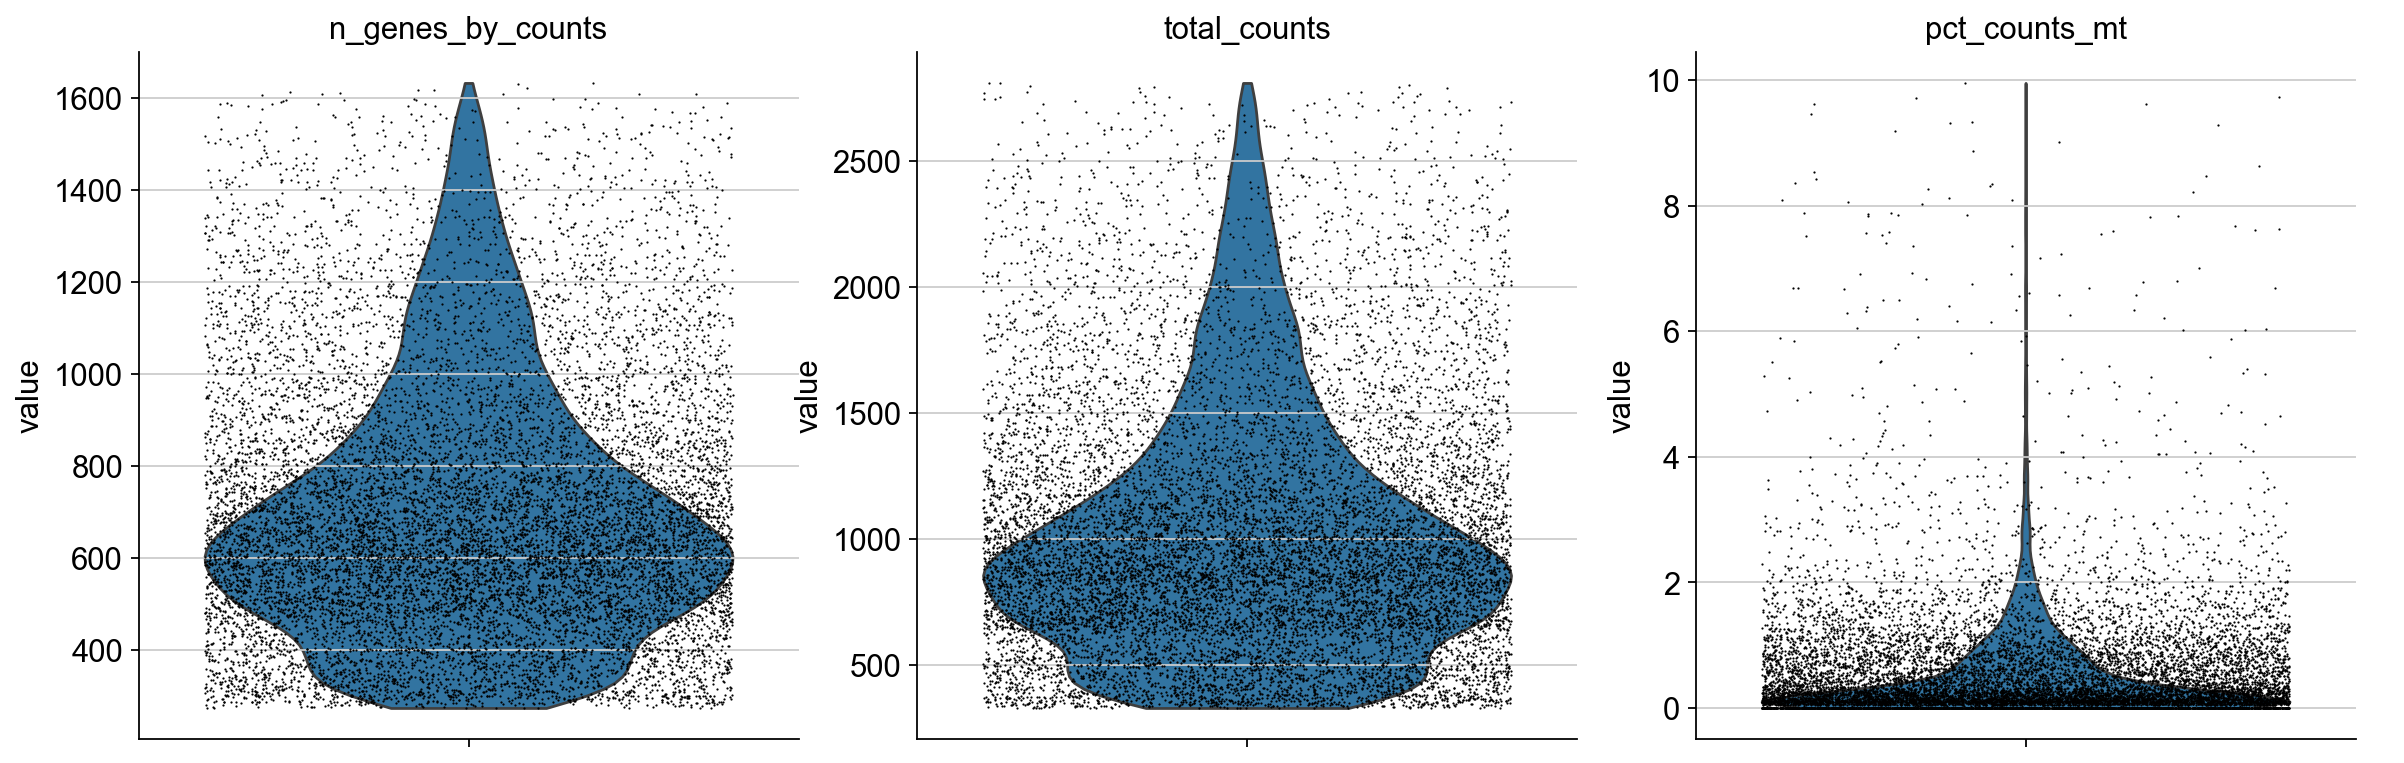

In [9]:
sc.pl.violin(adata,['n_genes_by_counts','total_counts','pct_counts_mt'],
              jitter=0.4,multi_panel=True)

In [10]:
sc.pp.filter_cells(adata,min_genes=200)

sc.pp.filter_genes(adata,min_cells=3)

adata = adata[adata.obs.pct_counts_mt < 5,:]

print(f"清洗完毕！剩余细胞数：{adata.n_obs}")


清洗完毕！剩余细胞数：13096


##3.样本量统计(AD vs Control)

---样本分布统计---
oupSample.batchCond
AD    6564
ct    6532
Name: count, dtype: int64


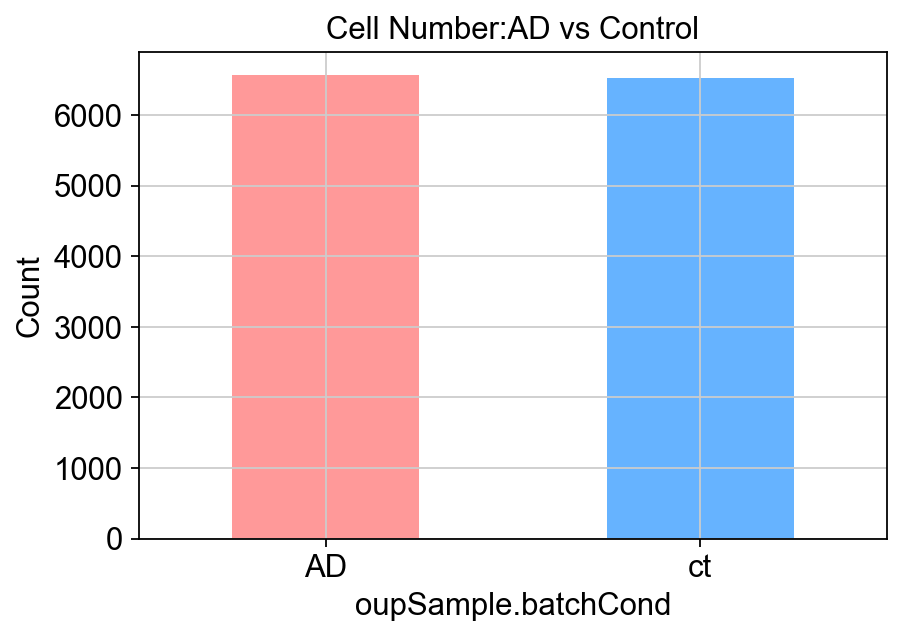

In [11]:
target_col = 'oupSample.batchCond'

if target_col in adata.obs.columns:
   
    summary = adata.obs[target_col].value_counts()
    print("---样本分布统计---")
    print(summary)

    import matplotlib.pyplot as plt
    summary.plot(kind='bar',color=['#ff9999','#66b3ff'],figsize=(6,4))
    plt.title('Cell Number:AD vs Control')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()
else:
    print("还是没找到，请运行 print(adata.obs.columns)把结果发给我")

##4.UMAP降维与聚类可视化

d:\miniconda\envs\sc_env\lib\site-packages\scanpy\preprocessing\_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:10)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


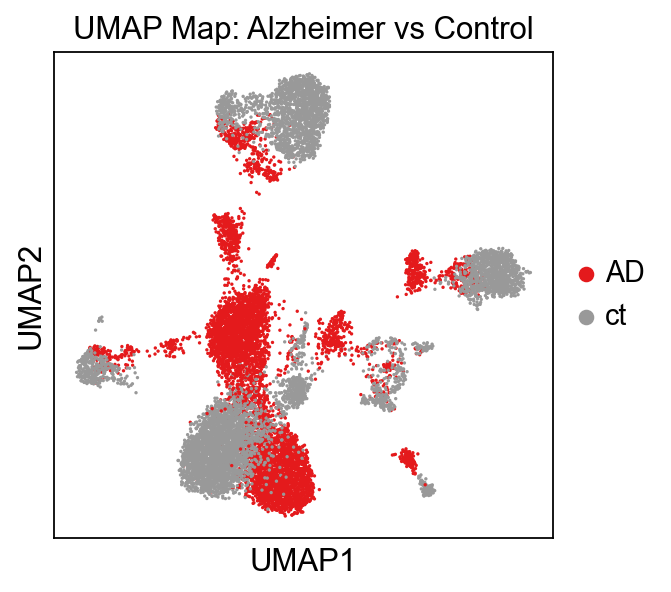

In [17]:
sc.pp.normalize_total(adata,target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata)
sc.pp.neighbors(adata,n_neighbors=10,n_pcs=40)
sc.tl.umap(adata)

sc.pl.umap(adata,color=['oupSample.batchCond'],
           title='UMAP Map: Alzheimer vs Control',
           palette='Set1')